# Data-driven convection of a Darcy fluid in a porous rectangle

In [ ]:
from typing import Callable
from functools import partial
import numpy as np
from PIL import Image
from scipy.interpolate import RegularGridInterpolator
from lucifex.fdm import AB1, CN
from lucifex.sim import run
from lucifex.mesh import as_grid_mesh
from lucifex.fem import cross_section_grid
from lucifex.utils.npy_utils import as_index
from lucifex.plt import (
    plot_contours, plot_line,
    plot_colormap_multifigure, save_figure,
)
from py.C19_darcy_data_driven import darcy_convection_data_driven


def mock_boundary_data(
    t,
    eps_x: float,
    eps_t: float,
    omega_x: float,
    omega_t: float,
    Lx: float,
) -> Callable[[np.ndarray], np.ndarray]:
    f = lambda t: 1 + eps_t * np.sin(omega_t * float(t))
    return lambda x: (
        4 * Lx * x[0] * (Lx - x[0])
        * (1 + eps_x * np.sin(omega_x * f(t) * np.pi * x[0] / Lx))
        / (1 + eps_x)
    )

def mock_porosity_data(
    img_path: str,
    Lx: float,
    Ly: float,
    eps: float = 0.1,
) -> Callable[[np.ndarray], np.ndarray]:
    img = np.array(Image.open(img_path).convert("L"))[::-1, :]
    img_normalised = eps + (img - np.min(img)) / np.max(img) 
    x_axis = np.linspace(0, Lx, num=img.shape[0])
    y_axis = np.linspace(0, Ly, num=img.shape[1])
    interpolator = RegularGridInterpolator(
        (x_axis, y_axis), 
        img_normalised,
        bounds_error=False,
        fill_value=eps,
    )
    return lambda x: interpolator(np.stack([x[1], x[0]], axis=-1)).flatten()


aspect = 1.0
c_lower = partial(
    mock_boundary_data, 
    eps_x=0.1,
    eps_t=3.0,
    omega_x=6.0,
    omega_t=1.0,
    Lx=aspect,
)
porosity = mock_porosity_data("./figures/prof_woods.png", aspect, 1.0)

simulation = darcy_convection_data_driven(
    aspect=aspect,  
    Nx=64,
    Ny=64,
    cell='quadrilateral', 
    scaling='advective',
    Ra=1000.0, 
    c_lower=c_lower,
    porosity=porosity,
    D_adv=AB1,
    D_diff=CN,
    dt_max=0.1,
    dt_min=0.05,
    # diagnostic=True,
)

n_stop = 200
run(simulation, n_stop=n_stop)

c, cD, psi = simulation['c', 'cD', 'psi']
phi, k = simulation['phi', 'k']

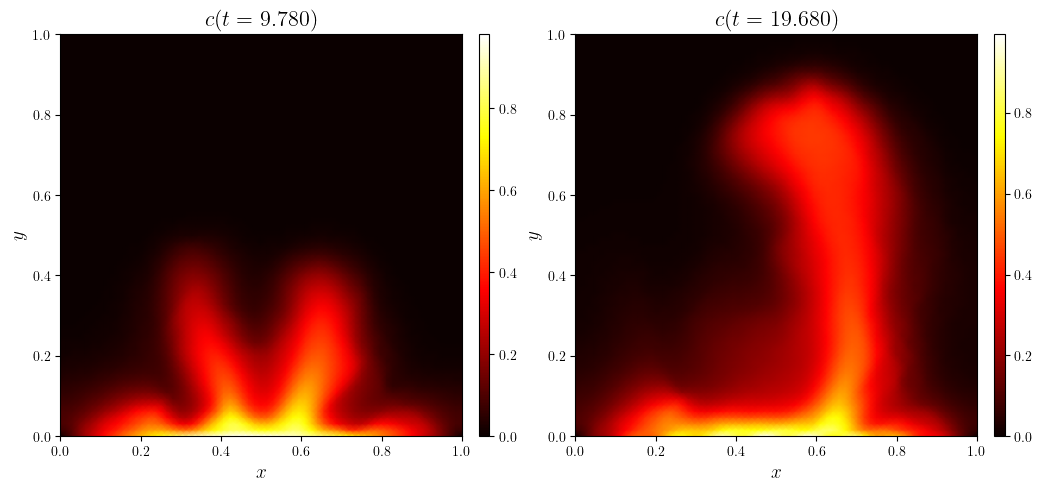

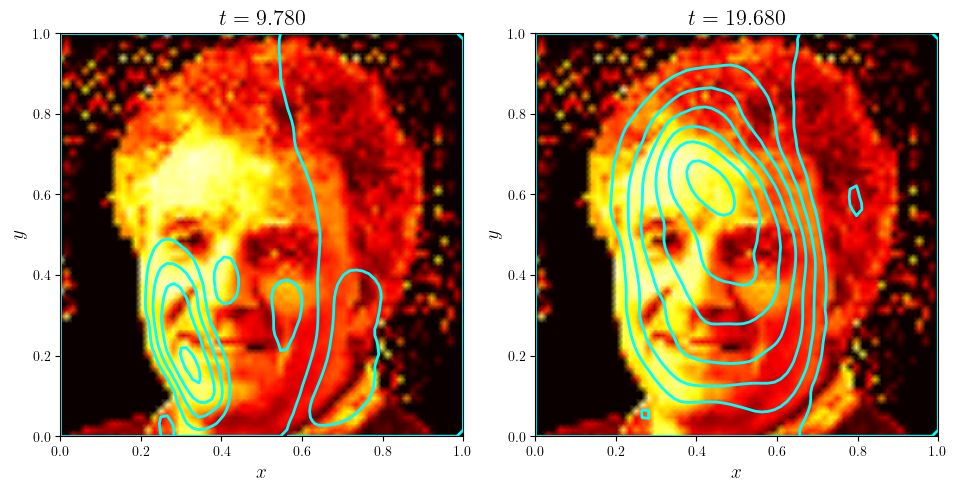

In [ ]:
time_indices = as_index(c.time_series, (0.5, -1), fraction=True)
c_cmaps, psi_contours, c_titles, t_titles = [], [], [], []
for i in time_indices:
    c_cmaps.append(c.series[i])
    psi_contours.append(psi.series[i])
    teq = f't={c.time_series[i]:.3f}'
    t_titles.append(f'${teq}$')
    c_titles.append(f'$c({teq})$')

mfig, *_ = plot_colormap_multifigure(n_rows=1, cbars=True)(
    c_cmaps, title=c_titles,
)
save_figure('c(x,y,t)')(mfig)

mfig, axs, _ = plot_colormap_multifigure(n_rows=1, cbars=False)(
    [phi] * len(psi_contours), title=t_titles,
)
for ax, cntr in zip(axs, psi_contours):
    plot_contours(mfig, ax, cntr, colors='cyan', linewidths=2)
save_figure('k(x,y)_streamlines', thumbnail=True)(mfig)



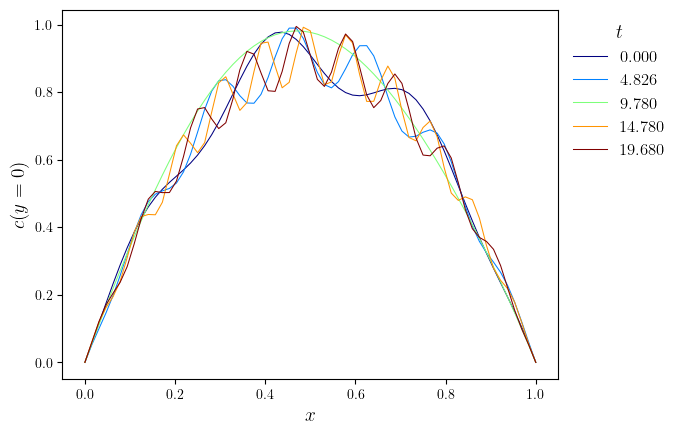

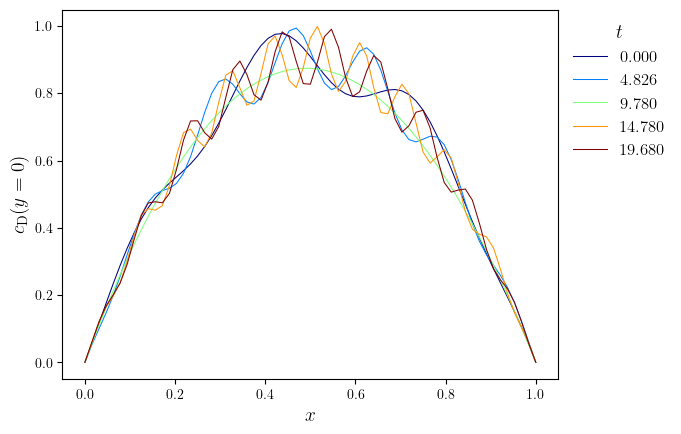

In [ ]:
time_indices = as_index(c.time_series, (0, 0.25, 0.5, 0.75, -1), fraction=True)
x_axis = as_grid_mesh(c.mesh).x_axis

cD_lines, c_lines, labels = [], [], []
for i in time_indices:
    ti = c.time_series[i]
    c_cs, _ = cross_section_grid(c.series[i], 'y', 0, use_cache=False)
    cD_lines.append((x_axis, c_lower(ti)([x_axis])))
    c_lines.append(c_cs)
    labels.append(f'{ti:.3f}')

line_kws = dict(
    x_label='$x$', 
    cyc='jet',
    legend_labels=labels,
    legend_title='$t$',
)

fig, ax = plot_line(c_lines, **line_kws, y_label='$c(y=0)$')
fig, ax = plot_line(cD_lines, **line_kws, y_label='$c_{\mathrm{D}}(y=0)$')
